# 🧬 Docking Molecular Automatizado
**Pipeline:** AutoDock Vina · fpocket · py3Dmol · RDKit

---
Este notebook realiza docking molecular de forma semi-automatizada:
1. Instalación de dependencias
2. Carga de estructuras (receptor y ligando)
3. Limpieza y preparación del receptor
4. Preparación del ligando
5. Detección automática de cavidades (fpocket)
6. Ejecución del docking (AutoDock Vina)
7. Análisis y visualización de resultados


---
## 📦 SECCIÓN 1 — Instalación de librerías
Ejecuta esta celda **una sola vez** al inicio. Puede tardar 3-5 minutos.

In [ ]:
import subprocess, sys

def run(cmd, desc=''):
    print(f'  ⏳ {desc}...' if desc else '', end='', flush=True)
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if r.returncode != 0:
        print(f' ❌\n{r.stderr[-300:]}')
    else:
        print(' ✅')
    return r

print('📦 [1/4] Instalando dependencias del sistema...')
run('apt-get update -qq', 'apt update')
run('apt-get install -y -qq openbabel libopenbabel-dev cmake git wget unzip libnetcdf-dev', 'openbabel + cmake + git')

print('\n🕳️  [2/4] Compilando fpocket desde fuente...')
run('rm -rf /tmp/fpocket', 'limpiando')
run('git clone -q https://github.com/Discngine/fpocket.git /tmp/fpocket', 'clonando repo')
run('make -C /tmp/fpocket -j$(nproc) 2>&1 | tail -5', 'compilando (puede tardar ~1 min)')
run('cp /tmp/fpocket/bin/fpocket /usr/local/bin/fpocket && chmod +x /usr/local/bin/fpocket', 'instalando binario')
run('fpocket --help 2>&1 | head -3', 'verificando fpocket')

print('\n🚀 [3/4] Instalando AutoDock Vina...')
VINA_URL = 'https://github.com/ccsb-scripps/AutoDock-Vina/releases/download/v1.2.5/vina_1.2.5_linux_x86_64'
run(f'wget -q {VINA_URL} -O /usr/local/bin/vina && chmod +x /usr/local/bin/vina', 'descargando Vina v1.2.5')
r = subprocess.run('vina --version', shell=True, capture_output=True, text=True)
print(f'  Vina: {r.stdout.strip() or r.stderr.strip()}')

print('\n🐍 [4/4] Instalando librerías Python...')
run(f'{sys.executable} -m pip install -q rdkit meeko gemmi vina py3Dmol biopython pandas numpy matplotlib', 'pip install')

print('\n' + '═'*45)
print('  ✅ INSTALACIÓN COMPLETA')
print('═'*45)

📦 [1/4] Instalando dependencias del sistema...
  ⏳ apt update... ✅
  ⏳ openbabel + cmake + git... ✅

🕳️  [2/4] Compilando fpocket desde fuente...
  ⏳ limpiando... ✅
  ⏳ clonando repo... ✅
  ⏳ compilando (puede tardar ~1 min)... ✅
  ⏳ instalando binario... ✅
  ⏳ verificando fpocket... ✅

🚀 [3/4] Instalando AutoDock Vina...
  ⏳ descargando Vina v1.2.5... ✅
  Vina: AutoDock Vina v1.2.5

🐍 [4/4] Instalando librerías Python...
  ⏳ pip install... ✅

═════════════════════════════════════════════
  ✅ INSTALACIÓN COMPLETA
═════════════════════════════════════════════


In [ ]:
# ── Verificación de imports ───────────────────────────────────────────────────
import sys, subprocess, os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import py3Dmol

from rdkit import Chem
from rdkit.Chem import AllChem, Draw, Descriptors
from rdkit.Chem.Draw import IPythonConsole

from Bio import PDB
from Bio.PDB import PDBParser, PDBIO, Select

import meeko

WORKDIR = Path("/content/docking")
WORKDIR.mkdir(exist_ok=True)
(WORKDIR / "input").mkdir(exist_ok=True)
(WORKDIR / "prepared").mkdir(exist_ok=True)
(WORKDIR / "results").mkdir(exist_ok=True)

print("✅ Todas las librerías cargadas correctamente.")
print(f"📁 Directorio de trabajo: {WORKDIR}")

✅ Todas las librerías cargadas correctamente.
📁 Directorio de trabajo: /content/docking


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---
## 📂 SECCIÓN 2 — Carga de estructuras

Sube tus archivos usando el panel de **Archivos** de Colab (ícono de carpeta a la izquierda), o usa las celdas de carga interactiva a continuación.

**Formatos aceptados:**
- Receptor: `.pdb`
- Ligando: `.sdf`, `.mol2`, `.pdb`, `.mol`

In [ ]:
# ── Carga interactiva de archivos ─────────────────────────────────────────────
from google.colab import files
import shutil

print("📤 Sube el archivo del RECEPTOR (proteína .pdb):")
uploaded_receptor = files.upload()

for fname, data in uploaded_receptor.items():
    dest = WORKDIR / "input" / fname
    dest.write_bytes(data)
    RECEPTOR_RAW = dest
    print(f"   ✅ Receptor guardado: {dest}")

📤 Sube el archivo del RECEPTOR (proteína .pdb):


Saving 2BQV.pdb to 2BQV.pdb
   ✅ Receptor guardado: /content/docking/input/2BQV.pdb


In [ ]:
print("📤 Sube el archivo del LIGANDO (.sdf / .mol2 / .pdb / .mol):")
uploaded_ligando = files.upload()

for fname, data in uploaded_ligando.items():
    dest = WORKDIR / "input" / fname
    dest.write_bytes(data)
    LIGAND_RAW = dest
    print(f"   ✅ Ligando guardado: {dest}")

📤 Sube el archivo del LIGANDO (.sdf / .mol2 / .pdb / .mol):


Saving Structure2D_COMPOUND_CID_5327090.sdf to Structure2D_COMPOUND_CID_5327090.sdf
   ✅ Ligando guardado: /content/docking/input/Structure2D_COMPOUND_CID_5327090.sdf


In [ ]:
# ── Visualización inicial del receptor (antes de limpiar) ─────────────────────
with open(RECEPTOR_RAW) as f:
    pdb_raw = f.read()

view = py3Dmol.view(width=860, height=540)
view.addModel(pdb_raw, 'pdb')

view.setStyle(
    {'hetflag': False},
    {'cartoon': {'color': 'spectrum', 'opacity': 0.85}}
)

view.setStyle(
    {'resn': 'HOH'},
    {'sphere': {'color': 'red', 'radius': 0.4}}
)
view.setStyle(
    {'resn': 'WAT'},
    {'sphere': {'color': 'red', 'radius': 0.4}}
)

import re
hetatm_resnames = set()
for line in pdb_raw.splitlines():
    if line.startswith('HETATM'):
        resname = line[17:20].strip()
        if resname not in ('HOH', 'WAT', 'H2O', 'DOD'):
            hetatm_resnames.add(resname)

print(f'   HETATMs detectados: {sorted(hetatm_resnames)}')

for resname in hetatm_resnames:
    view.setStyle(
        {'resn': resname},
        {'stick':  {'colorscheme': 'greenCarbon', 'radius': 0.25},
         'sphere': {'colorscheme': 'greenCarbon', 'radius': 0.20}}
    )

view.zoomTo()
view.spin(False)
view.show()

print('🔭 Visualización inicial del receptor (sin limpiar)')
print('   🌈 Arcoíris  = proteína (cartoon)')
print('   🔴 Rojo      = moléculas de agua')
print('   🟢 Verde     = ligandos co-cristalizados, iones, HETATMs')

parser_raw = PDBParser(QUIET=True)
struct_raw  = parser_raw.get_structure("raw", RECEPTOR_RAW)
n_aguas  = sum(1 for r in struct_raw.get_residues() if r.resname.strip() in ('HOH','WAT','H2O'))
n_hetatm = sum(1 for r in struct_raw.get_residues() if r.id[0] not in (' ','W') and r.resname.strip() not in ('HOH','WAT','H2O'))
n_aa     = sum(1 for r in struct_raw.get_residues() if r.id[0] == ' ')
print(f'\n   Aminoácidos : {n_aa}')
print(f'   Aguas       : {n_aguas}')
print(f'   Otros HETATM: {n_hetatm}')
if hetatm_resnames:
    print(f'   → {", ".join(sorted(hetatm_resnames))}')

   HETATMs detectados: ['A1A']


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

🔭 Visualización inicial del receptor (sin limpiar)
   🌈 Arcoíris  = proteína (cartoon)
   🔴 Rojo      = moléculas de agua
   🟢 Verde     = ligandos co-cristalizados, iones, HETATMs

   Aminoácidos : 198
   Aguas       : 47
   Otros HETATM: 1
   → A1A


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ── Info básica del receptor ──────────────────────────────────────────────────
parser = PDBParser(QUIET=True)
structure = parser.get_structure("receptor", RECEPTOR_RAW)

n_atoms    = sum(1 for _ in structure.get_atoms())
n_residues = sum(1 for _ in structure.get_residues())
n_chains   = sum(1 for _ in structure.get_chains())
n_models   = len(list(structure.get_models()))

hetero_residues = [
    r for r in structure.get_residues()
    if r.id[0] not in (" ", "W")
]
water_residues = [
    r for r in structure.get_residues()
    if r.id[0] == "W" or r.resname in ("HOH", "WAT", "H2O")
]

print("═" * 45)
print(f"  📋 INFORMACIÓN DEL RECEPTOR")
print("═" * 45)
print(f"  Modelos    : {n_models}")
print(f"  Cadenas    : {n_chains}")
print(f"  Residuos   : {n_residues}")
print(f"  Átomos     : {n_atoms}")
print(f"  Aguas      : {len(water_residues)}")
print(f"  Hetero-mol : {len(hetero_residues)} (ligandos co-cristalizados, iones, etc.)")
print("═" * 45)

if hetero_residues:
    print("\n  🔎 Moléculas HETATM detectadas:")
    seen = set()
    for r in hetero_residues:
        key = r.resname
        if key not in seen:
            print(f"     - {key}")
            seen.add(key)

═════════════════════════════════════════════
  📋 INFORMACIÓN DEL RECEPTOR
═════════════════════════════════════════════
  Modelos    : 1
  Cadenas    : 2
  Residuos   : 246
  Átomos     : 1606
  Aguas      : 47
  Hetero-mol : 1 (ligandos co-cristalizados, iones, etc.)
═════════════════════════════════════════════

  🔎 Moléculas HETATM detectadas:
     - A1A


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---
## 🧹 SECCIÓN 3 — Limpieza del receptor

Se realizarán los siguientes pasos:
1. Remover moléculas de agua
2. Remover ligandos co-cristalizados y HETATMs no deseados
3. Conservar solo el primer modelo y cadenas seleccionadas
4. Añadir hidrógenos polares
5. Asignar cargas parciales (Gasteiger)
6. Exportar a `.pdbqt` para AutoDock Vina

In [ ]:
# ── Configuración de limpieza ─────────────────────────────────────────────────

CADENAS_A_CONSERVAR = None

HETATM_CONSERVAR   = []

REMOVER_AGUAS       = True

print("⚙️  Configuración de limpieza:")
print(f"   Cadenas a conservar : {CADENAS_A_CONSERVAR or 'Todas'}")
print(f"   HETATM a conservar  : {HETATM_CONSERVAR or 'Ninguno'}")
print(f"   Remover aguas       : {REMOVER_AGUAS}")

⚙️  Configuración de limpieza:
   Cadenas a conservar : Todas
   HETATM a conservar  : Ninguno
   Remover aguas       : True


In [ ]:
class ReceptorSelector(Select):
    def __init__(self, cadenas=None, hetatm_conservar=None, remover_aguas=True):
        self.cadenas         = cadenas
        self.hetatm_conservar = set(hetatm_conservar or [])
        self.remover_aguas   = remover_aguas

    def accept_model(self, model):
        return model.id == 0

    def accept_chain(self, chain):
        if self.cadenas is None:
            return True
        return chain.id in self.cadenas

    def accept_residue(self, residue):
        hetflag = residue.id[0]
        resname  = residue.resname.strip()

        if hetflag == "W" or resname in ("HOH", "WAT", "H2O"):
            return not self.remover_aguas

        if hetflag not in (" ", ""):
            return resname in self.hetatm_conservar

        return True

    def accept_atom(self, atom):
        return atom.element != "H"

parser    = PDBParser(QUIET=True)
structure = parser.get_structure("receptor", RECEPTOR_RAW)

RECEPTOR_CLEAN = WORKDIR / "prepared" / "receptor_clean.pdb"

io = PDBIO()
io.set_structure(structure)
io.save(
    str(RECEPTOR_CLEAN),
    ReceptorSelector(
        cadenas=CADENAS_A_CONSERVAR,
        hetatm_conservar=HETATM_CONSERVAR,
        remover_aguas=REMOVER_AGUAS
    )
)

structure_clean = parser.get_structure("clean", RECEPTOR_CLEAN)
n_atoms_clean   = sum(1 for _ in structure_clean.get_atoms())

print("✅ Limpieza completada:")
print(f"   Átomos antes : {n_atoms}")
print(f"   Átomos después: {n_atoms_clean}")
print(f"   Eliminados   : {n_atoms - n_atoms_clean}")
print(f"   Archivo      : {RECEPTOR_CLEAN}")

✅ Limpieza completada:
   Átomos antes : 1606
   Átomos después: 1516
   Eliminados   : 90
   Archivo      : /content/docking/prepared/receptor_clean.pdb


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ── Añadir hidrógenos polares y convertir a PDBQT ─────────────────────────────

RECEPTOR_PDBQT = WORKDIR / "prepared" / "receptor.pdbqt"

cmd = [
    "obabel",
    str(RECEPTOR_CLEAN),
    "-O", str(RECEPTOR_PDBQT),
    "-p", "7.4",
    "--partialcharge", "gasteiger",
    "-xr",
]

result = subprocess.run(cmd, capture_output=True, text=True)

if RECEPTOR_PDBQT.exists():
    print("✅ Receptor preparado como PDBQT:")
    print(f"   Archivo: {RECEPTOR_PDBQT}")
    print(f"   Tamaño : {RECEPTOR_PDBQT.stat().st_size / 1024:.1f} KB")
else:
    print("❌ Error en conversión PDBQT:")
    print(result.stderr)

✅ Receptor preparado como PDBQT:
   Archivo: /content/docking/prepared/receptor.pdbqt
   Tamaño : 144.4 KB


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ── Visualizar receptor limpio ────────────────────────────────────────────────
with open(RECEPTOR_CLEAN) as f:
    pdb_clean = f.read()

view = py3Dmol.view(width=800, height=500)
view.addModel(pdb_clean, "pdb")
view.setStyle({"cartoon": {"color": "lightblue"}})
view.setStyle({"hetflag": True}, {"stick": {"color": "orange"}})
view.zoomTo()
view.show()
print("🔭 Receptor limpio (azul = proteína, naranja = cofactores conservados si aplica)")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

🔭 Receptor limpio (azul = proteína, naranja = cofactores conservados si aplica)


---
## ⚗️ SECCIÓN 4 — Preparación del ligando

Pasos:
1. Lectura del archivo con RDKit (soporta `.sdf`, `.mol2`, `.mol`, `.pdb`)
2. Generación de conformación 3D si no existe
3. Optimización de geometría (MMFF94)
4. Asignación de cargas Gasteiger
5. Conversión a `.pdbqt` con **meeko** (define enlaces rotables automáticamente)

In [ ]:
# ── Lectura del ligando con RDKit ─────────────────────────────────────────────
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, Draw
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import display, Image
import meeko
from meeko import MoleculePreparation, PDBQTWriterLegacy

ext = LIGAND_RAW.suffix.lower()

if ext == '.sdf':
    suppl = Chem.SDMolSupplier(str(LIGAND_RAW), removeHs=False)
    mol = next(m for m in suppl if m is not None)
elif ext == '.mol2':
    mol = Chem.MolFromMol2File(str(LIGAND_RAW), removeHs=False)
elif ext == '.mol':
    mol = Chem.MolFromMolFile(str(LIGAND_RAW), removeHs=False)
elif ext == '.pdb':
    mol = Chem.MolFromPDBFile(str(LIGAND_RAW), removeHs=False)
else:
    raise ValueError(f'Formato no soportado: {ext}. Usa .sdf, .mol2, .mol o .pdb')

if mol is None:
    raise ValueError('RDKit no pudo leer el ligando. Verifica el archivo.')

print('✅ Ligando leído correctamente')
print(f'   Nombre       : {mol.GetProp("_Name") if mol.HasProp("_Name") else "Sin nombre"}')
print(f'   Átomos       : {mol.GetNumAtoms()}')
print(f'   Átomos pesados: {mol.GetNumHeavyAtoms()}')
print(f'   Peso Mol.    : {Descriptors.MolWt(mol):.2f} Da')
print(f'   LogP         : {Descriptors.MolLogP(mol):.2f}')
print(f'   TPSA         : {Descriptors.TPSA(mol):.2f} Å²')
print(f'   HBD / HBA    : {Descriptors.NumHDonors(mol)} / {Descriptors.NumHAcceptors(mol)}')
print(f'   Rot. bonds   : {Descriptors.NumRotatableBonds(mol)}')

✅ Ligando leído correctamente
   Nombre       : 5327090
   Átomos       : 83
   Átomos pesados: 43
   Peso Mol.    : 588.71 Da
   LogP         : 2.65
   TPSA         : 140.23 Å²
   HBD / HBA    : 5 / 7
   Rot. bonds   : 14


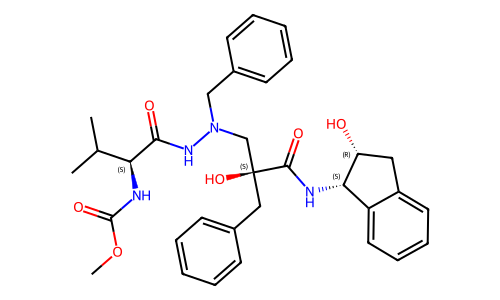

🧪 Estructura 2D del ligando


In [ ]:
# ── Imagen 2D del ligando ─────────────────────────────────────────────────────
mol2d = Chem.RWMol(mol)
mol2d = Chem.RemoveHs(mol2d)
AllChem.Compute2DCoords(mol2d)

drawer = rdMolDraw2D.MolDraw2DCairo(500, 300)
drawer.drawOptions().addStereoAnnotation = True
drawer.DrawMolecule(mol2d)
drawer.FinishDrawing()

img_path = WORKDIR / 'prepared' / 'ligando_2d.png'
img_path.write_bytes(drawer.GetDrawingText())
display(Image(str(img_path)))
print('🧪 Estructura 2D del ligando')

In [ ]:
# ── Generar conformación 3D robusta ──────────────────────────────────────────

from rdkit.Chem import rdMolDescriptors

def generar_3d_robusto(mol_input):
    """
    Pipeline de 4 estrategias para obtener una conformación 3D válida.
    Siempre parte del grafo 2D (SMILES) para evitar coordenadas corruptas.
    """
    mol2d = Chem.RemoveHs(mol_input)
    smiles = Chem.MolToSmiles(mol2d)
    print(f'   SMILES: {smiles}')
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise RuntimeError('No se pudo reconstruir la molécula desde SMILES.')
    mol = Chem.AddHs(mol)

    print('   [1/4] ETKDGv3...')
    params = AllChem.ETKDGv3()
    params.randomSeed       = 42
    params.maxIterations    = 1000
    params.enforceChirality = True
    params.useSmallRingTorsions = True
    params.useMacrocycleTorsions = True
    if AllChem.EmbedMolecule(mol, params) != -1:
        print('      Embedding OK ✅')
        return mol, 'ETKDGv3'

    print('   [2/4] ETKDGv3 sin quiralidad forzada...')
    params.enforceChirality = False
    mol_fresh = Chem.AddHs(Chem.MolFromSmiles(smiles))
    if AllChem.EmbedMolecule(mol_fresh, params) != -1:
        print('      Embedding OK ✅')
        return mol_fresh, 'ETKDGv3 (sin quiralidad)'

    print('   [3/4] ETKDG v1 clásico...')
    mol_fresh2 = Chem.AddHs(Chem.MolFromSmiles(smiles))
    if AllChem.EmbedMolecule(mol_fresh2, AllChem.ETKDG()) != -1:
        print('      Embedding OK ✅')
        return mol_fresh2, 'ETKDG v1'

    print('   [4/4] Coordenadas aleatorias + minimización forzada...')
    mol_fresh3 = Chem.AddHs(Chem.MolFromSmiles(smiles))
    params_rand = AllChem.ETKDGv3()
    params_rand.randomSeed = 42
    params_rand.useRandomCoords = True
    params_rand.enforceChirality = False
    params_rand.maxIterations = 5000
    if AllChem.EmbedMolecule(mol_fresh3, params_rand) != -1:
        print('      Embedding OK ✅')
        return mol_fresh3, 'Coords. aleatorias'

    raise RuntimeError(
        'Ninguna estrategia generó conformación 3D.\n'
        'Intenta limpiar el SMILES manualmente o usar un archivo .sdf con 3D precomputado.'
    )


def optimizar_geometria(mol):
    """
    Optimización en 2 pasos: MMFF94 primero, UFF de respaldo.
    Verifica convergencia y reporta energía final.
    """
    # Intentar MMFF94
    props = AllChem.MMFFGetMoleculeProperties(mol, mmffVariant='MMFF94s')
    if props is not None:
        ff = AllChem.MMFFGetMoleculeForceField(mol, props)
        if ff:
            ff.Minimize(maxIts=500)
            conv = ff.Minimize(maxIts=2000)
            energia = ff.CalcEnergy()
            estado  = 'convergió' if conv == 0 else 'no convergió (aceptable)'
            print(f'   MMFF94s: {estado}, E = {energia:.2f} kcal/mol ✅')
            return 'MMFF94s'

    print('   MMFF94 no disponible, usando UFF...')
    conv = AllChem.UFFOptimizeMolecule(mol, maxIts=2000)
    estado = 'convergió' if conv == 0 else 'no convergió (aceptable)'
    print(f'   UFF: {estado} ✅')
    return 'UFF'

print('🔨 Generando conformación 3D desde SMILES (geometría limpia garantizada)...')
mol, metodo_embed = generar_3d_robusto(mol)
print(f'   Método de embedding : {metodo_embed}')

print('⚙️  Optimizando geometría...')
metodo_opt = optimizar_geometria(mol)

conf   = mol.GetConformer()
coords = conf.GetPositions()
dists  = []
for bond in mol.GetBonds():
    i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
    d = float(np.linalg.norm(coords[i] - coords[j]))
    dists.append(d)

d_min, d_max = min(dists), max(dists)
ok = 0.8 < d_min and d_max < 2.5
print(f'   Longitud de enlace mín/máx: {d_min:.3f} / {d_max:.3f} Å  →  {"✅ OK" if ok else "⚠️  Revisar"}')

LIGAND_PDB = WORKDIR / 'prepared' / 'ligando_opt.pdb'
Chem.MolToPDBFile(mol, str(LIGAND_PDB))
print(f'   Guardado: {LIGAND_PDB}')

🔨 Generando conformación 3D desde SMILES (geometría limpia garantizada)...
   SMILES: COC(=O)N[C@H](C(=O)NN(Cc1ccccc1)C[C@@](O)(Cc1ccccc1)C(=O)N[C@H]1c2ccccc2C[C@H]1O)C(C)C
   [1/4] ETKDGv3...
      Embedding OK ✅
   Método de embedding : ETKDGv3
⚙️  Optimizando geometría...
   MMFF94s: convergió, E = 136.45 kcal/mol ✅
   Longitud de enlace mín/máx: 0.981 / 1.569 Å  →  ✅ OK
   Guardado: /content/docking/prepared/ligando_opt.pdb


In [ ]:
# ── Cargas Gasteiger + conversión a PDBQT con meeko ──────────────────────────
AllChem.ComputeGasteigerCharges(mol)

preparador = MoleculePreparation()
mol_setups = preparador.prepare(mol)

LIGAND_PDBQT = WORKDIR / 'prepared' / 'ligando.pdbqt'
pdbqt_str, is_ok, error_msg = PDBQTWriterLegacy.write_string(mol_setups[0])

if not is_ok:
    raise RuntimeError(f'Error generando PDBQT del ligando: {error_msg}')

LIGAND_PDBQT.write_text(pdbqt_str)

n_torsiones = pdbqt_str.count('BRANCH')

print('✅ Ligando preparado como PDBQT:')
print(f'   Archivo    : {LIGAND_PDBQT}')
print(f'   Torsiones  : {n_torsiones}')
print(f'   Tamaño     : {LIGAND_PDBQT.stat().st_size} bytes')

✅ Ligando preparado como PDBQT:
   Archivo    : /content/docking/prepared/ligando.pdbqt
   Torsiones  : 30
   Tamaño     : 4816 bytes


In [ ]:
# ── Visualización 3D del ligando ──────────────────────────────────────────────
with open(LIGAND_PDB) as f:
    lig_pdb = f.read()

view = py3Dmol.view(width=600, height=400)
view.addModel(lig_pdb, 'pdb')
view.setStyle({'stick': {'colorscheme': 'cyanCarbon'}})
view.addSurface(py3Dmol.SAS, {'opacity': 0.4, 'color': 'lightcyan'})
view.zoomTo()
view.spin(False)
view.show()
print('🔭 Conformación 3D del ligando optimizado')

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

🔭 Conformación 3D del ligando optimizado


---
## 🕳️ SECCIÓN 5 — Detección automática de cavidades (fpocket)

fpocket analiza la superficie del receptor y detecta **bolsillos druggables**. Se selecciona automáticamente el pocket con mayor puntaje de drugabilidad para definir el **grid box** de Vina.

> 💡 Puedes cambiar `POCKET_SELECCIONADO` para probar con otro bolsillo.

In [ ]:
# ── Detección de cavidades: intenta fpocket, si falla usa detector Python puro ─
import re, warnings
from scipy.spatial import KDTree
from sklearn.cluster import DBSCAN

def leer_coordenadas_pdb(pdb_path, solo_pesados=True):
    """Lee coordenadas y tipos de átomo de un PDB. Devuelve array (N,3) y lista de elementos."""
    coords, elems = [], []
    for line in Path(pdb_path).read_text().splitlines():
        if not line.startswith(('ATOM','HETATM')):
            continue
        elem = line[76:78].strip() if len(line) > 76 else line[12:14].strip()[0]
        if solo_pesados and elem == 'H':
            continue
        try:
            x, y, z = float(line[30:38]), float(line[38:46]), float(line[46:54])
            coords.append([x, y, z])
            elems.append(elem)
        except ValueError:
            pass
    return np.array(coords), elems


def detectar_cavidades_python(pdb_path, paso=1.2, radio_sonda=1.4, radio_bolsillo=3.5,
                               min_puntos=30, n_pockets=10):
    """
    Detector de cavidades en Python puro (sin qhull/fpocket).
    Algoritmo: grid de puntos candidatos → filtrar expuestos → filtrar enterrados
    → clustering DBSCAN → ranking por tamaño y compacidad.
    """
    coords, _ = leer_coordenadas_pdb(pdb_path)
    if len(coords) == 0:
        raise ValueError('No se encontraron átomos en el PDB.')

    vdw = {'C':1.7,'N':1.55,'O':1.52,'S':1.8,'P':1.8,'F':1.47,
           'CL':1.75,'BR':1.85,'I':1.98,'default':1.7}

    tree = KDTree(coords)

    pad  = 4.0
    mn   = coords.min(axis=0) - pad
    mx   = coords.max(axis=0) + pad
    xs   = np.arange(mn[0], mx[0], paso)
    ys   = np.arange(mn[1], mx[1], paso)
    zs   = np.arange(mn[2], mx[2], paso)
    grid = np.array([[x,y,z] for x in xs for y in ys for z in zs])

    dists_prot, _ = tree.query(grid, k=1)
    candidatos = grid[(dists_prot > radio_sonda) & (dists_prot < radio_bolsillo + radio_sonda)]

    if len(candidatos) == 0:
        raise RuntimeError('No se encontraron puntos candidatos. Ajusta radio_bolsillo.')
    vecinos = tree.query_ball_point(candidatos, r=radio_bolsillo)
    n_vec   = np.array([len(v) for v in vecinos])
    umbral  = np.percentile(n_vec, 40)
    enterrados = candidatos[n_vec >= umbral]

    if len(enterrados) < min_puntos:
        raise RuntimeError(f'Solo {len(enterrados)} puntos enterrados, muy pocos para clusterizar.')

    labels = DBSCAN(eps=paso*2.5, min_samples=min_puntos//3).fit_predict(enterrados)
    ids_validos = [l for l in set(labels) if l != -1]

    if not ids_validos:
        raise RuntimeError('DBSCAN no encontró clusters. Ajusta los parámetros.')

    pockets = []
    for i, lid in enumerate(ids_validos):
        pts    = enterrados[labels == lid]
        centro = pts.mean(axis=0)
        dims   = pts.max(axis=0) - pts.min(axis=0)
        vol    = max(dims.prod(), 1.0)
        score  = len(pts) / vol * 100
        pockets.append({
            'pocket'   : i + 1,
            'n_puntos' : len(pts),
            'score'    : round(score, 3),
            'centro_x' : round(float(centro[0]), 2),
            'centro_y' : round(float(centro[1]), 2),
            'centro_z' : round(float(centro[2]), 2),
            'dim_x'    : round(float(dims[0]) + 10, 1),
            'dim_y'    : round(float(dims[1]) + 10, 1),
            'dim_z'    : round(float(dims[2]) + 10, 1),
            '_puntos'  : pts,
        })

    pockets.sort(key=lambda p: p['score'], reverse=True)
    for rank, p in enumerate(pockets, 1):
        p['pocket'] = rank

    return pockets[:n_pockets]

USE_FPOCKET = False
fpocket_ok  = False
stem        = RECEPTOR_CLEAN.stem
fpocket_dir = WORKDIR / f'{stem}_out'

result_fp = subprocess.run(
    f'cd {WORKDIR} && timeout 60 fpocket -f {RECEPTOR_CLEAN}',
    shell=True, capture_output=True, text=True
)
if fpocket_dir.exists() and list((fpocket_dir / 'pockets').glob('pocket*_atm.pdb')):
    fpocket_ok = True
    print('✅ fpocket OK — usando resultados de fpocket')
else:
    print('⚠️  fpocket falló (qhull crash). Usando detector de cavidades Python puro...')

if fpocket_ok:
    pockets_dir  = fpocket_dir / 'pockets'
    pockets_data = []
    for atm_pdb in sorted(pockets_dir.glob('pocket*_atm.pdb')):
        num    = int(re.search(r'pocket(\d+)', atm_pdb.name).group(1))
        coords = []
        for line in Path(atm_pdb).read_text().splitlines():
            if line.startswith(('ATOM','HETATM')):
                try:
                    coords.append([float(line[30:38]), float(line[38:46]), float(line[46:54])])
                except ValueError:
                    pass
        if not coords:
            continue
        arr = np.array(coords)
        centro = arr.mean(axis=0)
        dims   = arr.max(axis=0) - arr.min(axis=0)
        pockets_data.append({
            'pocket': num, 'score': len(coords),
            'n_puntos': len(coords),
            'centro_x': round(float(centro[0]),2), 'centro_y': round(float(centro[1]),2), 'centro_z': round(float(centro[2]),2),
            'dim_x': round(float(dims[0])+10,1), 'dim_y': round(float(dims[1])+10,1), 'dim_z': round(float(dims[2])+10,1),
            '_puntos': arr,
        })
    info_txt = fpocket_dir / f'{stem}_info.txt'
    if info_txt.exists():
        raw    = info_txt.read_text()
        blocks = re.split(r'Pocket \d+', raw)[1:]
        for i, block in enumerate(blocks):
            if i < len(pockets_data):
                m = re.search(r'Druggability Score\s*:\s*([\d.]+)', block)
                pockets_data[i]['score'] = float(m.group(1)) if m else pockets_data[i]['score']
    POCKETS = sorted(pockets_data, key=lambda p: p['score'], reverse=True)
else:
    subprocess.run(f'{sys.executable} -m pip install -q scipy scikit-learn', shell=True)
    from scipy.spatial import KDTree
    from sklearn.cluster import DBSCAN
    POCKETS = detectar_cavidades_python(RECEPTOR_CLEAN)

df_pockets = pd.DataFrame([{k:v for k,v in p.items() if k != '_puntos'} for p in POCKETS])

print('\n' + '═'*72)
print('  📊 POCKETS / CAVIDADES DETECTADAS')
print('═'*72)
cols = ['pocket','score','n_puntos','centro_x','centro_y','centro_z','dim_x','dim_y','dim_z']
cols = [c for c in cols if c in df_pockets.columns]
print(df_pockets[cols].to_string(index=False))
print('═'*72)

⚠️  fpocket falló (qhull crash). Usando detector de cavidades Python puro...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



════════════════════════════════════════════════════════════════════════
  📊 POCKETS / CAVIDADES DETECTADAS
════════════════════════════════════════════════════════════════════════
 pocket  score  n_puntos  centro_x  centro_y  centro_z  dim_x  dim_y  dim_z
      1 12.997     17852     15.91      26.4      3.75   53.2   65.2   67.6
════════════════════════════════════════════════════════════════════════


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ── Seleccionar cavidad y definir grid box ─────────────────────────────────────
POCKET_SELECCIONADO = 1

pocket_row = df_pockets[df_pockets['pocket'] == POCKET_SELECCIONADO].iloc[0]
pocket_obj = next(p for p in POCKETS if p['pocket'] == POCKET_SELECCIONADO)

GRID_CENTER_X = float(pocket_row['centro_x'])
GRID_CENTER_Y = float(pocket_row['centro_y'])
GRID_CENTER_Z = float(pocket_row['centro_z'])
GRID_SIZE_X   = max(float(pocket_row['dim_x']), 20.0)
GRID_SIZE_Y   = max(float(pocket_row['dim_y']), 20.0)
GRID_SIZE_Z   = max(float(pocket_row['dim_z']), 20.0)

print('═' * 55)
print('  🎯 GRID BOX PARA AUTODOCK VINA')
print('═' * 55)
print(f'  Cavidad seleccionada : #{POCKET_SELECCIONADO}')
print(f'  Score                : {pocket_row["score"]:.4f}')
print(f'  Centro (X, Y, Z)     : {GRID_CENTER_X}, {GRID_CENTER_Y}, {GRID_CENTER_Z}')
print(f'  Tamaño (X, Y, Z) Å   : {GRID_SIZE_X}, {GRID_SIZE_Y}, {GRID_SIZE_Z}')
print('═' * 55)
print('\n💡 Cambia POCKET_SELECCIONADO y re-ejecuta para probar otro bolsillo.')

with open(RECEPTOR_CLEAN) as f:
    rec_pdb = f.read()

view = py3Dmol.view(width=820, height=520)
view.addModel(rec_pdb, 'pdb')
view.setStyle({'model': 0}, {'cartoon': {'color': 'lightblue', 'opacity': 0.65}})

pts = pocket_obj['_puntos']
pkt_lines = ['REMARK cavity']
for i, (x, y, z) in enumerate(pts[::3]):
    pkt_lines.append(
        f'HETATM{i+1:5d}  C   PKT A   1    {x:8.3f}{y:8.3f}{z:8.3f}  1.00  0.00           C'
    )
pkt_lines.append('END')

view.addModel('\n'.join(pkt_lines), 'pdb')
view.setStyle({'model': 1}, {'sphere': {'color': 'tomato', 'opacity': 0.45, 'radius': 0.6}})
view.addBox({
    'center'    : {'x': GRID_CENTER_X, 'y': GRID_CENTER_Y, 'z': GRID_CENTER_Z},
    'dimensions': {'w': GRID_SIZE_X,   'h': GRID_SIZE_Y,   'd': GRID_SIZE_Z},
    'color': 'gold', 'opacity': 0.15, 'wireframe': True
})
view.zoomTo({'model': 1})
view.show()
print(f'🔭 Azul = receptor | Rojo = cavidad #{POCKET_SELECCIONADO} | Amarillo = grid box Vina')

═══════════════════════════════════════════════════════
  🎯 GRID BOX PARA AUTODOCK VINA
═══════════════════════════════════════════════════════
  Cavidad seleccionada : #1
  Score                : 12.9970
  Centro (X, Y, Z)     : 15.91, 26.4, 3.75
  Tamaño (X, Y, Z) Å   : 53.2, 65.2, 67.6
═══════════════════════════════════════════════════════

💡 Cambia POCKET_SELECCIONADO y re-ejecuta para probar otro bolsillo.


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

🔭 Azul = receptor | Rojo = cavidad #1 | Amarillo = grid box Vina


---
## 🚀 SECCIÓN 6 — Ejecución del Docking (AutoDock Vina)

Se configura y lanza AutoDock Vina con los parámetros obtenidos de la detección de cavidades.

| Parámetro | Descripción |
|---|---|
| `EXHAUSTIVIDAD` | Nivel de búsqueda conformacional (8=rápido, 32=exhaustivo) |
| `N_POSES` | Número de poses a generar |
| `ENERGY_RANGE` | Rango de energía (kcal/mol) respecto a la mejor pose |

In [ ]:
# ── Parámetros del docking ─────────────────────────────────────────────────────
# Ajusta según tus necesidades
EXHAUSTIVIDAD = 16    # 8 = rápido, 16 = balanceado, 32 = exhaustivo
N_POSES       = 9     # Número de poses de salida
ENERGY_RANGE  = 3.0   # kcal/mol de rango

print('⚙️  Parámetros de docking:')
print(f'   Exhaustividad : {EXHAUSTIVIDAD}')
print(f'   N poses       : {N_POSES}')
print(f'   Energy range  : {ENERGY_RANGE} kcal/mol')
print(f'   Grid center   : ({GRID_CENTER_X}, {GRID_CENTER_Y}, {GRID_CENTER_Z})')
print(f'   Grid size     : ({GRID_SIZE_X}, {GRID_SIZE_Y}, {GRID_SIZE_Z}) Å')

⚙️  Parámetros de docking:
   Exhaustividad : 16
   N poses       : 9
   Energy range  : 3.0 kcal/mol
   Grid center   : (15.91, 26.4, 3.75)
   Grid size     : (53.2, 65.2, 67.6) Å


In [ ]:
# ── Escribir archivo de configuración de Vina ──────────────────────────────────
VINA_CONFIG  = WORKDIR / 'results' / 'vina_config.txt'
DOCKING_OUT  = WORKDIR / 'results' / 'poses.pdbqt'

config_text = f"""receptor = {RECEPTOR_PDBQT}
ligand   = {LIGAND_PDBQT}
out      = {DOCKING_OUT}

center_x = {GRID_CENTER_X}
center_y = {GRID_CENTER_Y}
center_z = {GRID_CENTER_Z}

size_x = {GRID_SIZE_X}
size_y = {GRID_SIZE_Y}
size_z = {GRID_SIZE_Z}

exhaustiveness = {EXHAUSTIVIDAD}
num_modes      = {N_POSES}
energy_range   = {ENERGY_RANGE}
"""

VINA_CONFIG.write_text(config_text)
print('✅ Archivo de configuración generado:')
print(config_text)

✅ Archivo de configuración generado:
receptor = /content/docking/prepared/receptor.pdbqt
ligand   = /content/docking/prepared/ligando.pdbqt
out      = /content/docking/results/poses.pdbqt

center_x = 15.91
center_y = 26.4
center_z = 3.75

size_x = 53.2
size_y = 65.2
size_z = 67.6

exhaustiveness = 16
num_modes      = 9
energy_range   = 3.0



In [ ]:
# ── Ejecutar Vina ──────────────────────────────────────────────────────────────
import time

print('🚀 Ejecutando AutoDock Vina...')
print('   (Puede tardar de 1 a varios minutos según exhaustividad)')
print('─' * 50)

t0 = time.time()
vina_proc = subprocess.run(
    f'vina --config {VINA_CONFIG}',
    shell=True, capture_output=True, text=True
)
t1 = time.time()

output = vina_proc.stdout + vina_proc.stderr
print(output)

DOCKING_LOG.write_text(output)
print(f'   Log guardado manualmente: {DOCKING_LOG}')

if DOCKING_OUT.exists():
    print('─' * 50)
    print(f'✅ Docking completado en {t1-t0:.1f} segundos')
    print(f'   Poses guardadas : {DOCKING_OUT}')
    print(f'   Log guardado    : {DOCKING_LOG}')
else:
    print('❌ Vina no generó archivo de salida. Revisa el output:')
    print(output[-500:])

🚀 Ejecutando AutoDock Vina...
   (Puede tardar de 1 a varios minutos según exhaustividad)
──────────────────────────────────────────────────
AutoDock Vina v1.2.5
#################################################################
# If you used AutoDock Vina in your work, please cite:          #
#                                                               #
# J. Eberhardt, D. Santos-Martins, A. F. Tillack, and S. Forli  #
# AutoDock Vina 1.2.0: New Docking Methods, Expanded Force      #
# Field, and Python Bindings, J. Chem. Inf. Model. (2021)       #
# DOI 10.1021/acs.jcim.1c00203                                  #
#                                                               #
# O. Trott, A. J. Olson,                                        #
# AutoDock Vina: improving the speed and accuracy of docking    #
# with a new scoring function, efficient optimization and       #
# multithreading, J. Comp. Chem. (2010)                         #
# DOI 10.1002/jcc.21334                       

NameError: name 'DOCKING_LOG' is not defined

---
## 📊 SECCIÓN 7 — Análisis y visualización de resultados

Se extraen las energías de cada pose, se genera un ranking y se visualizan las poses en el sitio de unión junto al receptor.

In [ ]:
# ── Parsear energías del log de Vina (con fallback al PDBQT) ──────────────────
def parsear_resultados_vina(log_file):
    """Extrae la tabla de resultados del log de AutoDock Vina."""
    resultados = []
    log_txt = Path(log_file).read_text()

    in_table = False
    for line in log_txt.splitlines():
        if '-----+------------+----------+----------' in line:
            in_table = True
            continue
        if in_table:
            parts = line.split()
            if len(parts) >= 4:
                try:
                    resultados.append({
                        'pose'     : int(parts[0]),
                        'afinidad' : float(parts[1]),
                        'rmsd_lb'  : float(parts[2]),
                        'rmsd_ub'  : float(parts[3]),
                    })
                except (ValueError, IndexError):
                    break

    return pd.DataFrame(resultados)


def parsear_energias_pdbqt(pdbqt_file):
    """
    Fallback: extrae energías directamente de los REMARKs del archivo
    poses.pdbqt generado por Vina.
    Líneas con formato: REMARK VINA RESULT:  -8.5  0.000  0.000
    """
    resultados = []
    pose = 0
    for line in Path(pdbqt_file).read_text().splitlines():
        if line.startswith('MODEL'):
            pose += 1
        if 'REMARK VINA RESULT' in line or 'REMARK  minimizedAffinity' in line:
            parts = line.split()
            try:
                vals = [float(x) for x in parts if x.replace('-','').replace('.','').isdigit() or
                        (x.startswith('-') and x[1:].replace('.','').isdigit())]
                if len(vals) >= 3:
                    resultados.append({
                        'pose': pose, 'afinidad': vals[0],
                        'rmsd_lb': vals[1], 'rmsd_ub': vals[2]
                    })
                elif len(vals) == 1:
                    resultados.append({
                        'pose': pose, 'afinidad': vals[0],
                        'rmsd_lb': 0.0, 'rmsd_ub': 0.0
                    })
            except (ValueError, IndexError):
                pass
    return pd.DataFrame(resultados)

df_resultados = parsear_resultados_vina(DOCKING_LOG)

if df_resultados.empty:
    print('⚠️  Log no contiene tabla de resultados. Extrayendo energías del PDBQT...')
    df_resultados = parsear_energias_pdbqt(DOCKING_OUT)

if df_resultados.empty:
    raise RuntimeError('No se pudieron extraer resultados. Verifica que Vina generó poses.')

print('═' * 55)
print('  🏆 RESULTADOS DE DOCKING — AutoDock Vina')
print('═' * 55)
print(f'  {"Pose":>4}  {"Afinidad (kcal/mol)":>20}  {"RMSD lb":>8}  {"RMSD ub":>8}')
print('  ' + '─' * 50)
for _, row in df_resultados.iterrows():
    marker = '  ◀ MEJOR' if row['pose'] == 1 else ''
    print(f'  {int(row["pose"]):>4}  {row["afinidad"]:>20.2f}  {row["rmsd_lb"]:>8.3f}  {row["rmsd_ub"]:>8.3f}{marker}')
print('═' * 55)
print(f'\n  Mejor afinidad : {df_resultados["afinidad"].min():.2f} kcal/mol')
print(f'  Peor afinidad  : {df_resultados["afinidad"].max():.2f} kcal/mol')

NameError: name 'DOCKING_LOG' is not defined

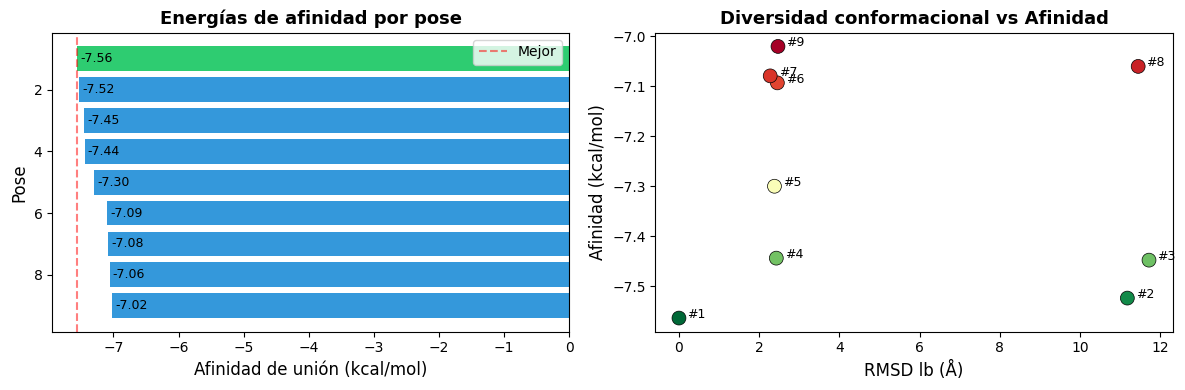

📈 Gráfico guardado en results/afinidades.png


In [ ]:
# ── Gráfico de afinidades ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colores = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(df_resultados))]
axes[0].barh(df_resultados['pose'], df_resultados['afinidad'], color=colores)
axes[0].set_xlabel('Afinidad de unión (kcal/mol)', fontsize=12)
axes[0].set_ylabel('Pose', fontsize=12)
axes[0].set_title('Energías de afinidad por pose', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
axes[0].axvline(x=df_resultados['afinidad'].min(), color='red', linestyle='--', alpha=0.5, label='Mejor')
axes[0].legend()
for i, row in df_resultados.iterrows():
    axes[0].text(row['afinidad'] + 0.05, row['pose'], f"{row['afinidad']:.2f}", va='center', fontsize=9)

axes[1].scatter(df_resultados['rmsd_lb'], df_resultados['afinidad'],
                c=df_resultados['afinidad'], cmap='RdYlGn_r', s=100, edgecolors='black', linewidths=0.5)
for _, row in df_resultados.iterrows():
    axes[1].annotate(f"#{int(row['pose'])}",
                     (row['rmsd_lb'], row['afinidad']),
                     textcoords='offset points', xytext=(6, 0), fontsize=9)
axes[1].set_xlabel('RMSD lb (Å)', fontsize=12)
axes[1].set_ylabel('Afinidad (kcal/mol)', fontsize=12)
axes[1].set_title('Diversidad conformacional vs Afinidad', fontsize=13, fontweight='bold')

plt.tight_layout()
fig.savefig(str(WORKDIR / 'results' / 'afinidades.png'), dpi=150, bbox_inches='tight')
plt.show()
print('📈 Gráfico guardado en results/afinidades.png')

In [ ]:
# ── Separar poses individuales ────────────────────────────────────────────────
def separar_poses_pdbqt(pdbqt_file, output_dir):
    """Divide el archivo multi-pose de Vina en PDB individuales."""
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True)

    contenido = Path(pdbqt_file).read_text()
    modelos = re.split(r'(?=MODEL\s+\d+)', contenido)
    modelos = [m for m in modelos if m.strip().startswith('MODEL')]

    archivos = []
    for modelo in modelos:
        num = re.search(r'MODEL\s+(\d+)', modelo).group(1)
        pdbqt_tmp = output_dir / f'pose_{num}.pdbqt'
        pdb_out   = output_dir / f'pose_{num}.pdb'
        pdbqt_tmp.write_text(modelo)
        subprocess.run(
            f'obabel {pdbqt_tmp} -O {pdb_out} -q',
            shell=True, capture_output=True
        )
        if pdb_out.exists():
            archivos.append(pdb_out)
        pdbqt_tmp.unlink(missing_ok=True)

    return sorted(archivos)

POSES_DIR  = WORKDIR / 'results' / 'poses'
pose_files = separar_poses_pdbqt(DOCKING_OUT, POSES_DIR)

print(f'✅ {len(pose_files)} poses separadas en: {POSES_DIR}')
for i, pf in enumerate(pose_files, 1):
    kcal = df_resultados.iloc[i-1]['afinidad'] if i <= len(df_resultados) else '?'
    print(f'   Pose {i}: {pf.name}  →  {kcal} kcal/mol')

✅ 9 poses separadas en: /content/docking/results/poses
   Pose 1: pose_1.pdb  →  -7.564 kcal/mol
   Pose 2: pose_2.pdb  →  -7.524 kcal/mol
   Pose 3: pose_3.pdb  →  -7.448 kcal/mol
   Pose 4: pose_4.pdb  →  -7.444 kcal/mol
   Pose 5: pose_5.pdb  →  -7.3 kcal/mol
   Pose 6: pose_6.pdb  →  -7.093 kcal/mol
   Pose 7: pose_7.pdb  →  -7.079 kcal/mol
   Pose 8: pose_8.pdb  →  -7.06 kcal/mol
   Pose 9: pose_9.pdb  →  -7.02 kcal/mol


In [ ]:
# ── Visualización: superficie proteína + ligando en sitio activo ──────────────
POSE_A_MOSTRAR = 1

best_pose_file = pose_files[POSE_A_MOSTRAR - 1]

with open(RECEPTOR_CLEAN) as f:
    rec_pdb = f.read()

with open(best_pose_file) as f:
    pose_data = f.read()

view = py3Dmol.view(width=900, height=620)

view.addModel(rec_pdb, 'pdb')

view.setStyle({'model': 0}, {})

view.addSurface(
    py3Dmol.VDW,
    {
        'opacity'     : 0.88,
        'color'       : 'white',
        'smoothness'  : 3,
    },
    {'model': 0}
)

view.addModel(pose_data, 'pdb')

view.setStyle(
    {'model': 1},
    {
        'stick': {
            'colorscheme' : 'RdBu',
            'radius'      : 0.20,
            'bondThickness': 0.18,
        }
    }
)

view.zoomTo({'model': 1})
view.spin(False)
view.show()

afinidad_best = df_resultados.iloc[POSE_A_MOSTRAR - 1]['afinidad']
print(f'🔭 Receptor (superficie) + Pose #{POSE_A_MOSTRAR} ({afinidad_best:.2f} kcal/mol)')
print(f'💡 Cambia POSE_A_MOSTRAR (1–{len(pose_files)}) y re-ejecuta.')

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

🔭 Receptor (superficie) + Pose #1 (-7.56 kcal/mol)
💡 Cambia POSE_A_MOSTRAR (1–9) y re-ejecuta.


In [ ]:
# ── Comparación: pose calculada vs ligando experimental (PDB de referencia) ───
from google.colab import files as colab_files
import re

print("📤 Sube el PDB del ligando experimental (cristalográfico):")
uploaded_ref = colab_files.upload()

for fname, data in uploaded_ref.items():
    REF_LIGAND_PDB = WORKDIR / 'results' / fname
    REF_LIGAND_PDB.write_bytes(data)
    print(f"   ✅ Referencia guardada: {REF_LIGAND_PDB}")

def calcular_rmsd(pdb_a, pdb_b):
    """
    RMSD átomo a átomo entre dos estructuras.
    Empareja por nombre de átomo, ignora hidrógenos.
    """
    def leer_atomos(pdb_path):
        coords = {}
        for line in Path(pdb_path).read_text().splitlines():
            if not line.startswith(('ATOM', 'HETATM')):
                continue
            elem = line[76:78].strip() if len(line) > 76 else ''
            if elem == 'H' or line[12:14].strip().startswith('H'):
                continue
            nombre = line[12:16].strip()
            try:
                x, y, z = float(line[30:38]), float(line[38:46]), float(line[46:54])
                coords[nombre] = np.array([x, y, z])
            except ValueError:
                pass
        return coords

    coords_a = leer_atomos(pdb_a)
    coords_b = leer_atomos(pdb_b)

    comunes = sorted(set(coords_a) & set(coords_b))
    if len(comunes) < 3:
        return None, comunes

    diffs = np.array([coords_a[n] - coords_b[n] for n in comunes])
    rmsd  = float(np.sqrt((diffs**2).sum(axis=1).mean()))
    return rmsd, comunes

best_pose_file = pose_files[0]  # pose 1 = mejor afinidad
rmsd, atomos_comunes = calcular_rmsd(best_pose_file, REF_LIGAND_PDB)

print()
print('═' * 52)
print('  📐 RMSD — Calculado vs Experimental')
print('═' * 52)
if rmsd is not None:
    print(f'  Átomos emparejados : {len(atomos_comunes)}')
    print(f'  RMSD               : {rmsd:.3f} Å')
    if rmsd <= 2.0:
        print(f'  Evaluación         : ✅ Excelente  (≤ 2.0 Å)')
    elif rmsd <= 3.0:
        print(f'  Evaluación         : 🟡 Aceptable  (2.0 – 3.0 Å)')
    else:
        print(f'  Evaluación         : ❌ Divergente (> 3.0 Å)')
else:
    print('  ⚠️  Muy pocos átomos en común — verifica que sea el mismo ligando.')
print('═' * 52)

with open(RECEPTOR_CLEAN) as f:
    rec_pdb = f.read()
with open(best_pose_file) as f:
    pose_calc = f.read()
with open(REF_LIGAND_PDB) as f:
    pose_ref = f.read()

view = py3Dmol.view(width=920, height=620)

view.addModel(rec_pdb, 'pdb')
view.setStyle({'model': 0}, {})
view.addSurface(
    py3Dmol.VDW,
    {'opacity': 0.82, 'color': 'white'},
    {'model': 0}
)

view.addModel(pose_calc, 'pdb')
view.setStyle(
    {'model': 1},
    {'stick': {'colorscheme': 'cyanCarbon', 'radius': 0.22},
     'sphere': {'colorscheme': 'cyanCarbon', 'radius': 0.18}}
)

view.addModel(pose_ref, 'pdb')
view.setStyle(
    {'model': 2},
    {'stick': {'colorscheme': 'orangeCarbon', 'radius': 0.22},
     'sphere': {'colorscheme': 'orangeCarbon', 'radius': 0.18}}
)

view.zoomTo({'model': 1})
view.spin(False)
view.show()

afinidad_best = df_resultados.iloc[0]['afinidad']
rmsd_str = f'{rmsd:.3f} Å' if rmsd is not None else 'N/A'
print(f'\n🔭 Superposición de poses')
print(f'   🩵 Cyan   = Pose calculada  (docking, {afinidad_best:.2f} kcal/mol)')
print(f'   🟠 Naranja = Pose experimental (cristalográfica)')
print(f'   📐 RMSD   = {rmsd_str}')
print(f'\n💡 Un RMSD ≤ 2.0 Å indica que el docking reproduce correctamente la pose experimental.')

📤 Sube el PDB del ligando experimental (cristalográfico):


Saving 2BQV.pdb to 2BQV (3).pdb
   ✅ Referencia guardada: /content/docking/results/2BQV (3).pdb

════════════════════════════════════════════════════
  📐 RMSD — Calculado vs Experimental
════════════════════════════════════════════════════
  Átomos emparejados : 3
  RMSD               : 28.290 Å
  Evaluación         : ❌ Divergente (> 3.0 Å)
════════════════════════════════════════════════════


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


🔭 Superposición de poses
   🩵 Cyan   = Pose calculada  (docking, -7.56 kcal/mol)
   🟠 Naranja = Pose experimental (cristalográfica)
   📐 RMSD   = 28.290 Å

💡 Un RMSD ≤ 2.0 Å indica que el docking reproduce correctamente la pose experimental.


In [ ]:
# ── Descargar resultados ───────────────────────────────────────────────────────
import zipfile
from google.colab import files as colab_files

ZIP_PATH = WORKDIR / 'resultados_docking.zip'

with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as zf:
    for pf in pose_files:
        zf.write(pf, f'poses/{pf.name}')
    zf.write(DOCKING_OUT, 'poses/todas_poses.pdbqt')
    zf.write(DOCKING_LOG, 'vina_log.txt')
    zf.write(VINA_CONFIG, 'vina_config.txt')
    zf.write(RECEPTOR_CLEAN,  'receptor/receptor_clean.pdb')
    zf.write(RECEPTOR_PDBQT,  'receptor/receptor.pdbqt')
    zf.write(LIGAND_PDBQT,    'ligando/ligando.pdbqt')
    zf.write(LIGAND_PDB,      'ligando/ligando_opt.pdb')
    csv_path = WORKDIR / 'results' / 'resultados.csv'
    df_resultados.to_csv(csv_path, index=False)
    zf.write(csv_path, 'resultados.csv')
    zf.write(WORKDIR / 'results' / 'afinidades.png', 'afinidades.png')

print(f'📦 ZIP generado: {ZIP_PATH} ({ZIP_PATH.stat().st_size/1024:.0f} KB)')
print('⬇️  Descargando...')
colab_files.download(str(ZIP_PATH))

📦 ZIP generado: /content/docking/resultados_docking.zip (161 KB)
⬇️  Descargando...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>